In [1]:
import xarray
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
#from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mticker

In [2]:
vname="clatlid"

vmin=0.
vmax=100.

### internal work

In [3]:
ds = xarray.open_dataset("../data/MIROC_outputs/ctrl_MIROC-COSP2.nc")

In [4]:
lat = ds["latitude"]
lon = ds["longitude"]
lev = ds["levStat"]

var = ds[vname]
var = var.where((var >= vmin) & (var <= vmax))


In [5]:
var = var.assign_coords(latitude=("loc", lat.data))
var_zonal = var.groupby("latitude").mean("loc")

In [6]:
colors=np.array(
   [
    [248,248,248,1],#white
    [160,210,255,1],
    [ 33,140,255,1],
    [  0, 65,255,1],
    [  0,185,  0,1],
    [250,245,  0,1],
    [255,153,  0,1],
    [255, 40,  0,1],
    [180,  0,104,1],
    [ 45, 45, 45,1],
   ],dtype=np.float64
)
colors[:,:3] /=256
color_listed=ListedColormap(colors)
color_linear=LinearSegmentedColormap.from_list('color_linear',colors=colors)

In [7]:
%%capture

fig, ax = plt.subplots(figsize=(16,9))

pcm = ax.pcolormesh(
    var_zonal.latitude,
    var_zonal.levStat,
    var_zonal,
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    cmap=color_linear
)

ax.set_title("zonal mean: "+vname, fontsize=32, pad=16)

ax.xaxis.set_major_locator(MultipleLocator(30.))
ax.set_xlabel("latitude",fontsize=22)

ax.yaxis.set_major_locator(MultipleLocator(3000.))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, pos: f"{y/1000:g}")
)
ax.set_ylabel("level (km)",fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=18)

cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("", fontsize=13)
cbar.ax.tick_params(labelsize=16)

plt.show()

NameError: name 'MultipleLocator' is not defined

### Figure

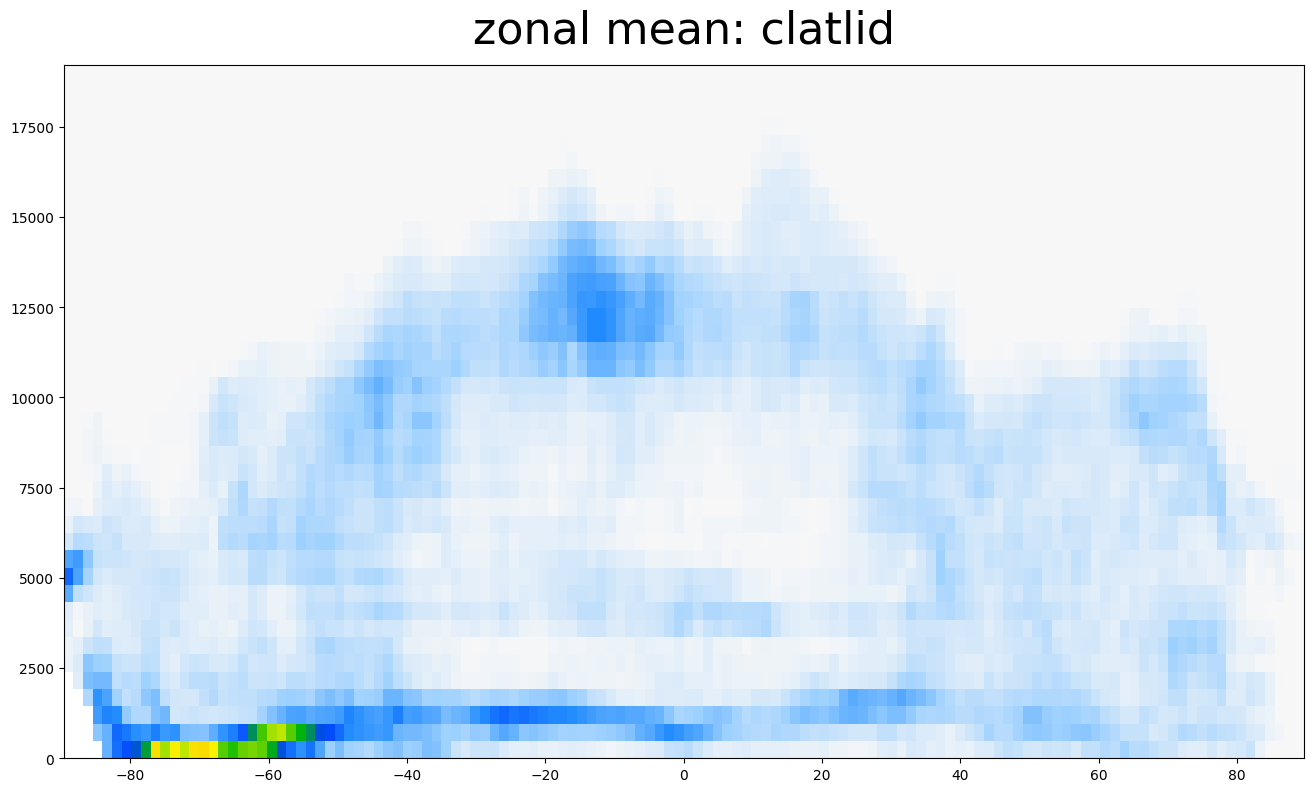

In [8]:
display(fig)